In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, balanced_accuracy_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [96]:
feature_names = [
    "n_C", "n_H", "n_N", "n_O", "n_NO", "n_halo", "tdu", "te",
    "A", "B", "C", "D", "E", "F", "G", "H",
    "mean_num", "mean_en", "max_en", "mean_d", "max_d",
    "a", "b", "c", "d", "e", "f", "g", "h", "i", "j"
]

voltage_columns = feature_names + ["class"]
core_columns = ["cof_id"] + feature_names

In [97]:
voltage_array = np.load("voltage_data.npy", allow_pickle=True)
core_array = np.load("core_cof_features-2.npy", allow_pickle=True)

dice_metadata = pd.read_excel("dice_wOCV_wcap.xlsx")

dice_df = pd.DataFrame(
    voltage_array,
    columns=voltage_columns
)

core_df = pd.DataFrame(
    core_array,
    columns=core_columns
)

# Add the DICE-C COF identifiers from the Excel file
dice_df.insert(
    0,
    "cof_id",
    dice_metadata["COF_numbers"].astype(str).to_numpy()
)

# Convert numerical columns explicitly
dice_df[feature_names + ["class"]] = dice_df[
    feature_names + ["class"]
].apply(pd.to_numeric, errors="coerce")

core_df[feature_names] = core_df[
    feature_names
].apply(pd.to_numeric, errors="coerce")

core_df["cof_id"] = core_df["cof_id"].astype(str)

print("DICE-V shape:", dice_df.shape)
print("CoRE shape:", core_df.shape)

assert len(dice_df) == len(dice_metadata), (
    "The Excel file and voltage_data.npy have different numbers of rows."
)

DICE-V shape: (137, 33)
CoRE shape: (997, 32)


In [47]:
core_df

,cof_id,n_C,n_H,n_N,n_O,n_NO,n_halo,tdu,te,A,...,a,b,c,d,e,f,g,h,i,j
0,1,0.483871,0.462366,0.032258,0.021505,0.053763,0.0,51.0,0.053763,2.0,...,7.399487e-02,32.393260,53.865893,5.771526e+01,29.609969,5.012952,18.769193,17.542155,0.000000,0.000000
1,100,0.437500,0.375000,0.000000,0.125000,0.125000,0.0,25.0,0.125000,11.0,...,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1001,0.571429,0.380952,0.047619,0.000000,0.047619,0.0,154.0,0.047619,18.0,...,1.636697e+02,613.774358,374.730110,2.356013e+02,148.934057,2.442729,0.000880,0.008937,3.412248,46.287042
3,1002,0.547619,0.380952,0.071429,0.000000,0.071429,0.0,67.0,0.071429,8.0,...,1.113142e+02,288.697702,110.270643,4.771490e+02,211.751448,101.111287,46.927641,3.639983,46.325995,43.917801
4,1003,0.550000,0.350000,0.100000,0.000000,0.100000,0.0,154.0,0.100000,6.0,...,4.000000e-08,313.054692,260.955205,2.794004e+01,4.438484,159.145329,0.000970,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,995,0.466667,0.400000,0.066667,0.066667,0.133333,0.0,28.0,0.133333,6.0,...,2.000000e-08,98.661443,48.702222,3.661201e-02,4.098256,0.000000,0.000000,0.000000,0.000000,0.000000
993,996,0.526316,0.315789,0.105263,0.052632,0.157895,0.0,25.0,0.157895,3.0,...,7.659292e+00,5.271865,19.908079,0.000000e+00,0.000000,0.001376,18.906903,0.000000,0.000000,0.000000
994,997,0.500000,0.333333,0.083333,0.083333,0.166667,0.0,28.0,0.166667,6.0,...,5.493520e+00,26.622468,76.679778,2.000000e-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
995,998,0.529412,0.352941,0.058824,0.058824,0.117647,0.0,40.0,0.117647,6.0,...,6.635191e+00,20.395608,67.064175,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
## Feature analysis OCV

In [98]:
def plot_feature_histogram(df, feature, bins=20):

    values = df[feature].dropna()
    bin_edges = np.histogram_bin_edges(values, bins=bins)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(6,5),
        sharex=True,
        gridspec_kw={"hspace":0}
    )

    colors = ["tab:blue", "tab:orange"]

    for ax, cls, color in zip([ax1, ax2], [0,1], colors):

        data = df.loc[df["class"]==cls, feature]
        weights = np.ones(len(data))/len(data)

        ax.hist(
            data,
            bins=bin_edges,
            weights=weights,
            color=color,
            edgecolor="black",
            linewidth=1,
            alpha=0.75,
        )

        #ax.text(
        #    0.98,
        #    0.90,
        #    f"Class {cls} (n={len(data)})",
        #    transform=ax.transAxes,
        #    ha="right",
        #    va="top",
        #    fontsize=11,
        #)

        ax.set_ylabel("Fraction")

        # Keep ALL borders
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

    # -----------------------------
    # Common axis between the plots
    # -----------------------------

    # Remove the duplicated line by hiding ONLY the bottom spine
    # of the upper subplot. The top spine of the lower subplot
    # becomes the common axis.
    ax1.spines["bottom"].set_visible(False)

    # Put x ticks on the top of the lower subplot
    ax1.tick_params(axis="x", bottom=False, labelbottom=False)

    # Hide x-axis ticks and labels on the top subplot
    ax1.tick_params(axis="x", bottom=False, labelbottom=False)

# Hide x-axis ticks on the top edge of the lower subplot
    ax2.tick_params(
    axis="x",
    top=False,
    labeltop=False,
    bottom=True,
    labelbottom=True,
    )

# Put the x-axis label below the lower subplot
    ax2.set_xlabel(feature)

    plt.tight_layout()
    plt.savefig(f'{feature}_dist.png', dpi = 600)
    plt.show()
    

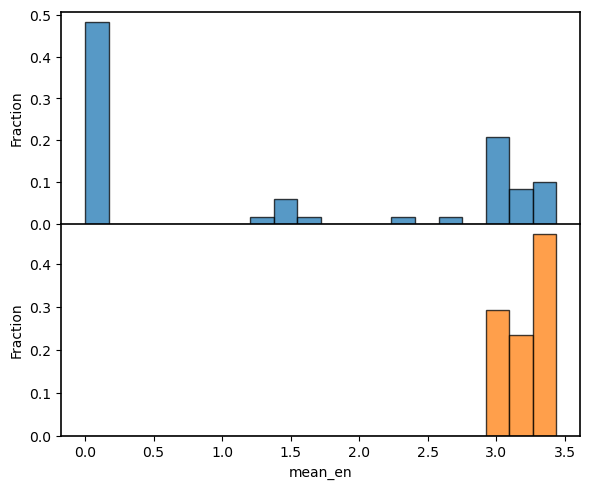

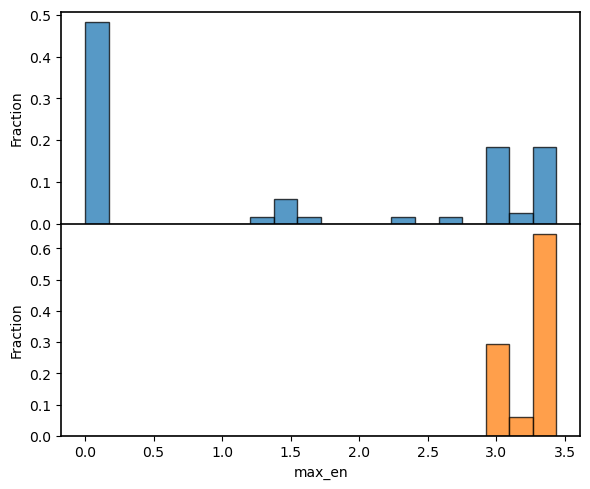

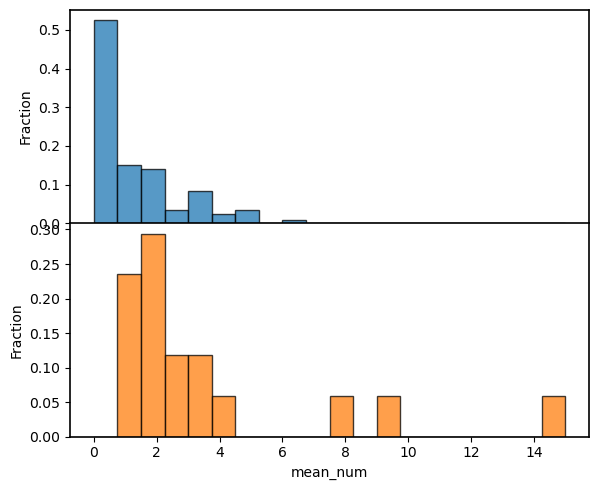

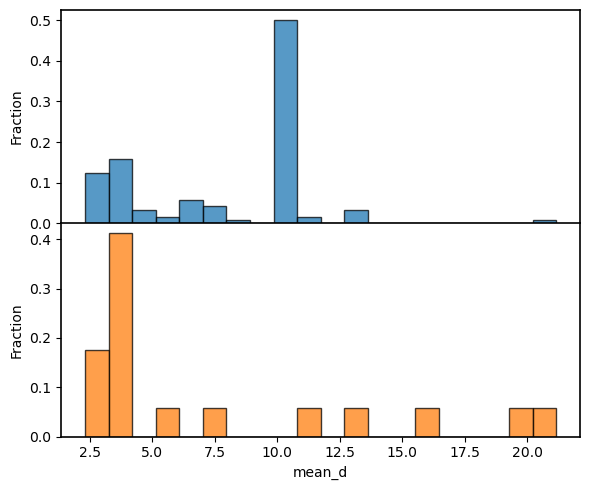

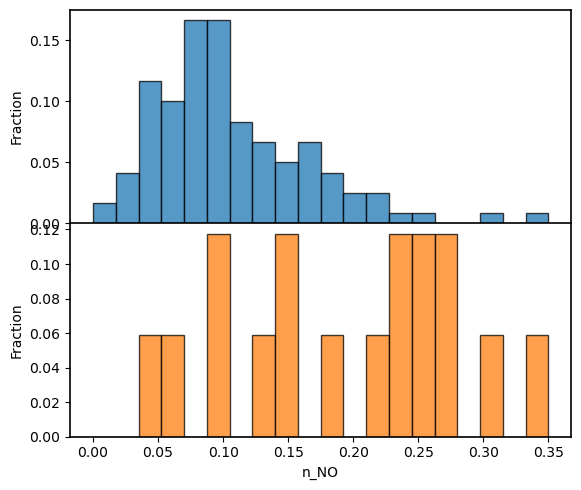

In [99]:
# features ocv
plot_feature_histogram(dice_df, "mean_en")
plot_feature_histogram(dice_df, "max_en")
plot_feature_histogram(dice_df, "mean_num")
plot_feature_histogram(dice_df, "mean_d")
plot_feature_histogram(dice_df, "n_NO")

In [108]:
dice_df.columns

Index(['cof_id', 'n_C', 'n_H', 'n_N', 'n_O', 'n_NO', 'n_halo', 'tdu', 'te',
       'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'mean_num', 'mean_en', 'max_en',
       'mean_d', 'max_d', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j',
       'class'],
      dtype='object')

In [109]:
cathode_cofs = dice_df.loc[(dice_df["mean_en"] > 3.0) & (dice_df["class"] == 1.0), dice_df.columns[0]]

print(len(cathode_cofs))
print(dice_df.loc[dice_df["mean_en"] > 3.0, [dice_df.columns[0], "mean_en"]])


17
    cof_id   mean_en
0     1049  3.240000
1     1100  3.240000
2     1133  3.040000
3      120  3.240000
4      148  3.040000
..     ...       ...
116    645  3.056667
117    664  3.040000
120    810  3.010000
121    848  3.040000
124    955  3.040000

[63 rows x 2 columns]


In [40]:
## Feature Analysis Cap

In [50]:
feature_names = [
    "n_C",
    "n_H",
    "n_N",
    "n_O",
    "n_NO",
    "n_halo",
    "tdu",
    "te",
    "MW",
    "nredox",
    "a_value",
    "b_value",
    "c_value",
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "c1",
    "c2",
    "c3",
    "c4",
    "c5",
    "c6",
    "c7",
    "c8",
    "mean_num'",
    "mean_en",
    "max_en",
    "mean_d",
    "max_d",
]


voltage_columns = feature_names + ["class"]
core_columns = ["cof_id"] + feature_names

In [51]:
voltage_array = np.load("../cap_classifier/cap_data_cls.npy", allow_pickle=True)
core_array = np.load("../cap_classifier/core_cof_features_4cap.npy", allow_pickle=True)

dice_metadata = pd.read_excel("dice_wOCV_wcap.xlsx",sheet_name="Final Stage")

dice_df = pd.DataFrame(
    voltage_array,
    columns=voltage_columns
)

core_df = pd.DataFrame(
    core_array,
    columns=core_columns
)

# Add the DICE-C COF identifiers from the Excel file
dice_df.insert(
    0,
    "cof_id",
    dice_metadata["COF_numbers"].astype(str).to_numpy()
)

# Convert numerical columns explicitly
dice_df[feature_names + ["class"]] = dice_df[
    feature_names + ["class"]
].apply(pd.to_numeric, errors="coerce")

core_df[feature_names] = core_df[
    feature_names
].apply(pd.to_numeric, errors="coerce")

core_df["cof_id"] = core_df["cof_id"].astype(str)

print("DICE-C shape:", dice_df.shape)
print("CoRE shape:", core_df.shape)

assert len(dice_df) == len(dice_metadata), (
    "The Excel file and voltage_data.npy have different numbers of rows."
)

DICE-C shape: (137, 38)
CoRE shape: (997, 37)


In [52]:
def plot_feature_histogram(df, feature, bins=20):

    values = df[feature].dropna()
    bin_edges = np.histogram_bin_edges(values, bins=bins)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(6,5),
        sharex=True,
        gridspec_kw={"hspace":0}
    )

    colors = ["tab:blue", "tab:orange"]

    for ax, cls, color in zip([ax1, ax2], [0,1], colors):

        data = df.loc[df["class"]==cls, feature]
        weights = np.ones(len(data))/len(data)

        ax.hist(
            data,
            bins=bin_edges,
            weights=weights,
            color=color,
            edgecolor="black",
            linewidth=1,
            alpha=0.75,
        )

        #ax.text(
        #    0.98,
        #    0.90,
        #    f"Class {cls} (n={len(data)})",
        #    transform=ax.transAxes,
        #    ha="right",
        #    va="top",
        #    fontsize=11,
        #)

        ax.set_ylabel("Fraction")

        # Keep ALL borders
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

    # -----------------------------
    # Common axis between the plots
    # -----------------------------

    # Remove the duplicated line by hiding ONLY the bottom spine
    # of the upper subplot. The top spine of the lower subplot
    # becomes the common axis.
    ax1.spines["bottom"].set_visible(False)

    # Put x ticks on the top of the lower subplot
    ax1.tick_params(axis="x", bottom=False, labelbottom=False)

    # Hide x-axis ticks and labels on the top subplot
    ax1.tick_params(axis="x", bottom=False, labelbottom=False)

# Hide x-axis ticks on the top edge of the lower subplot
    ax2.tick_params(
    axis="x",
    top=False,
    labeltop=False,
    bottom=True,
    labelbottom=True,
    )

# Put the x-axis label below the lower subplot
    ax2.set_xlabel(feature)

    plt.tight_layout()
    plt.savefig(f'../cap_classifier/{feature}_dist.png', dpi = 600)
    plt.show()
    

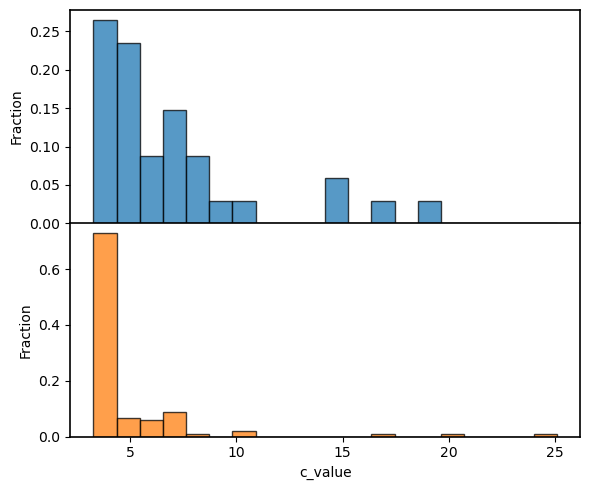

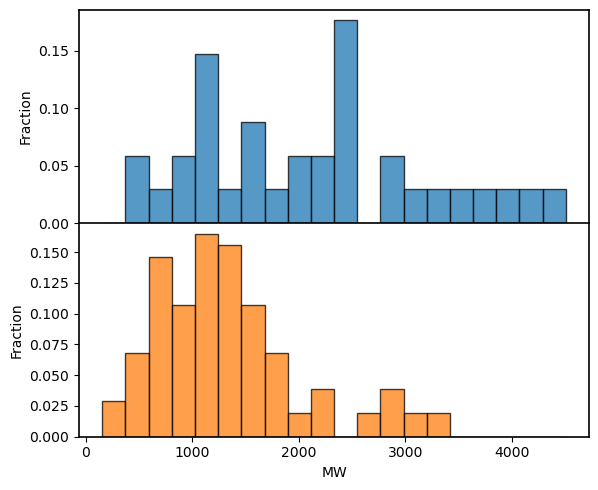

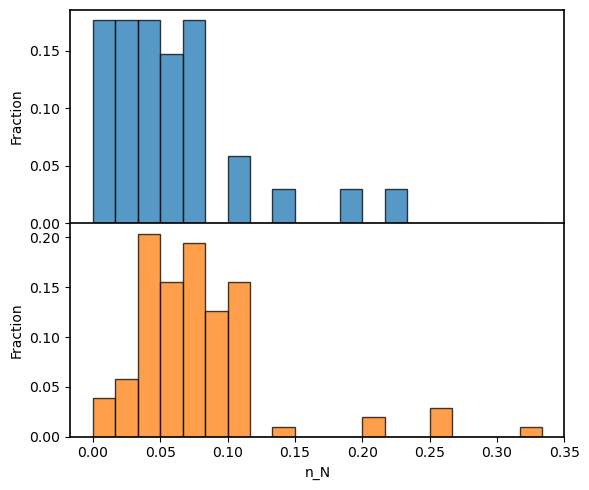

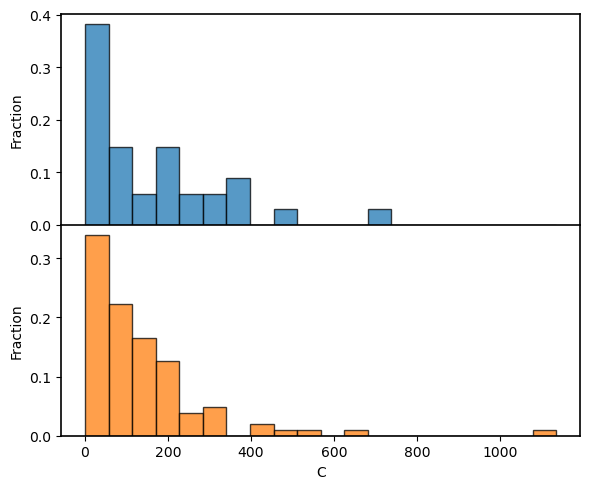

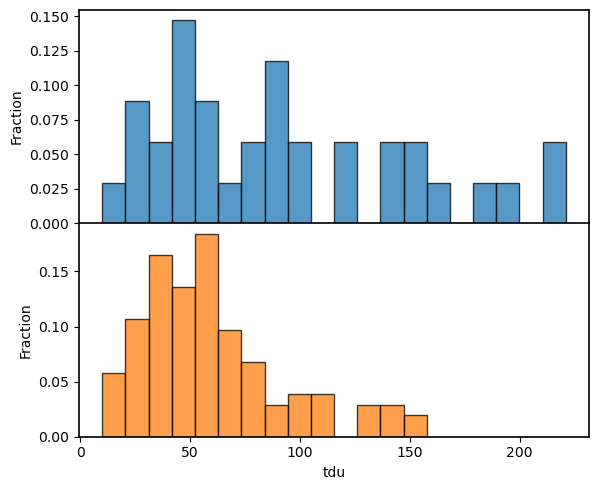

In [53]:
plot_feature_histogram(dice_df, "c_value")
plot_feature_histogram(dice_df, "MW")
plot_feature_histogram(dice_df, "n_N")
plot_feature_histogram(dice_df, "C")
plot_feature_histogram(dice_df, "tdu")

## AD analysis

In [84]:
feature_names = [
    "n_C", "n_H", "n_N", "n_O", "n_NO", "n_halo", "tdu", "te",
    "A", "B", "C", "D", "E", "F", "G", "H",
    "mean_num", "mean_en", "max_en", "mean_d", "max_d",
    "a", "b", "c", "d", "e", "f", "g", "h", "i", "j"
]

voltage_columns = feature_names + ["class"]
core_columns = ["cof_id"] + feature_names

In [85]:
voltage_array = np.load("voltage_data.npy", allow_pickle=True)
core_array = np.load("core_cof_features-2.npy", allow_pickle=True)

dice_metadata = pd.read_excel("dice_wOCV_wcap.xlsx")

dice_df = pd.DataFrame(
    voltage_array,
    columns=voltage_columns
)

core_df = pd.DataFrame(
    core_array,
    columns=core_columns
)

# Add the DICE-C COF identifiers from the Excel file
dice_df.insert(
    0,
    "cof_id",
    dice_metadata["COF_numbers"].astype(str).to_numpy()
)

# Convert numerical columns explicitly
dice_df[feature_names + ["class"]] = dice_df[
    feature_names + ["class"]
].apply(pd.to_numeric, errors="coerce")

core_df[feature_names] = core_df[
    feature_names
].apply(pd.to_numeric, errors="coerce")

core_df["cof_id"] = core_df["cof_id"].astype(str)

print("DICE-V shape:", dice_df.shape)
print("CoRE shape:", core_df.shape)

assert len(dice_df) == len(dice_metadata), (
    "The Excel file and voltage_data.npy have different numbers of rows."
)

DICE-V shape: (137, 33)
CoRE shape: (997, 32)


In [86]:
def normalize_cof_id(value):
    """
    Normalize COF identifiers before matching.
    """
    text = str(value).strip().lower().strip("'\"")

    for suffix in [".cif", ".xyz", ".pdb", ".vasp", ".mol", ".sdf"]:
        if text.endswith(suffix):
            text = text[:-len(suffix)]

    # Remove spaces, underscores, hyphens, punctuation, etc.
    return re.sub(r"[^a-z0-9]+", "", text)


dice_df["normalized_id"] = dice_df["cof_id"].map(normalize_cof_id)
core_df["normalized_id"] = core_df["cof_id"].map(normalize_cof_id)

dice_id_set = set(dice_df["normalized_id"])

overlap_mask = core_df["normalized_id"].isin(dice_id_set)

removed_overlap_df = core_df.loc[overlap_mask].copy()
core_filtered_df = core_df.loc[~overlap_mask].copy().reset_index(drop=True)

print(f"Original CoRE structures: {len(core_df)}")
print(f"Exact DICE-V overlaps removed: {len(removed_overlap_df)}")
print(f"Remaining filtered CoRE structures: {len(core_filtered_df)}")

removed_overlap_df[["cof_id", "normalized_id"]].head()

Original CoRE structures: 997
Exact DICE-V overlaps removed: 137
Remaining filtered CoRE structures: 860


,cof_id,normalized_id
6,1005,1005
15,1013,1013
27,1024,1024
30,1027,1027
36,1033,1033


In [87]:
coverage_imputer = SimpleImputer(strategy="median")
coverage_scaler = StandardScaler()

X_dice_imputed = coverage_imputer.fit_transform(
    dice_df[feature_names]
)

X_core_imputed = coverage_imputer.transform(
    core_filtered_df[feature_names]
)

X_dice_scaled = coverage_scaler.fit_transform(
    X_dice_imputed
)

X_core_scaled = coverage_scaler.transform(
    X_core_imputed
)

In [88]:
# For each DICE-C structure, find the nearest OTHER DICE-C structure
dice_nn = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean"
)

dice_nn.fit(X_dice_scaled)

dice_distances, dice_indices = dice_nn.kneighbors(
    X_dice_scaled
)

dice_internal_nn_distance = dice_distances[:, 1]


# For every filtered CoRE structure, find nearest DICE-C structure
core_nn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean"
)

core_nn.fit(X_dice_scaled)

core_distances, core_indices = core_nn.kneighbors(
    X_core_scaled
)

core_to_dice_distance = core_distances[:, 0]
core_nearest_dice_index = core_indices[:, 0]


ad_threshold_95 = np.quantile(
    dice_internal_nn_distance,
    0.95
)

inside_ad = core_to_dice_distance <= ad_threshold_95

print(f"95% training-domain threshold: {ad_threshold_95:.3f}")

print(
    f"Filtered CoRE inside AD: "
    f"{inside_ad.sum()} / {len(inside_ad)} "
    f"({100 * inside_ad.mean():.1f}%)"
)

print(
    f"Filtered CoRE outside AD: "
    f"{(~inside_ad).sum()} / {len(inside_ad)} "
    f"({100 * (~inside_ad).mean():.1f}%)"
)

95% training-domain threshold: 6.632
Filtered CoRE inside AD: 814 / 860 (94.7%)
Filtered CoRE outside AD: 46 / 860 (5.3%)


In [89]:
coverage_summary = pd.DataFrame({
    "distribution": [
        "DICE-C internal nearest neighbour",
        "Filtered CoRE to nearest DICE-C"
    ],
    "minimum": [
        np.min(dice_internal_nn_distance),
        np.min(core_to_dice_distance)
    ],
    "q25": [
        np.quantile(dice_internal_nn_distance, 0.25),
        np.quantile(core_to_dice_distance, 0.25)
    ],
    "median": [
        np.median(dice_internal_nn_distance),
        np.median(core_to_dice_distance)
    ],
    "q75": [
        np.quantile(dice_internal_nn_distance, 0.75),
        np.quantile(core_to_dice_distance, 0.75)
    ],
    "q95": [
        np.quantile(dice_internal_nn_distance, 0.95),
        np.quantile(core_to_dice_distance, 0.95)
    ],
    "maximum": [
        np.max(dice_internal_nn_distance),
        np.max(core_to_dice_distance)
    ]
})

coverage_summary

,distribution,minimum,q25,median,q75,q95,maximum
0,DICE-C internal nearest neighbour,0.255767,1.258593,1.931632,3.188886,6.632449,17.454743
1,Filtered CoRE to nearest DICE-C,0.000000,1.149539,1.888764,2.757124,6.967558,89.448670


In [90]:
coverage_summary.to_csv(
    "dice_core_coverage_summary.csv",
    index=False
)

In [91]:
core_coverage_df = pd.DataFrame({
    "core_id": core_filtered_df["cof_id"].to_numpy(),
    "nearest_dice_id": dice_df.iloc[
        core_nearest_dice_index
    ]["cof_id"].to_numpy(),
    "nearest_dice_distance": core_to_dice_distance,
    "inside_95pct_training_domain": inside_ad
}).sort_values(
    "nearest_dice_distance",
    ascending=False
)

core_coverage_df.to_csv(
    "filtered_core_domain_membership.csv",
    index=False
)

core_coverage_df.head(20)

,core_id,nearest_dice_id,nearest_dice_distance,inside_95pct_training_domain
628,69,955,89.448670,False
193,133,68,68.760033,False
645,712,664,36.424130,False
802,938,664,27.624953,False
280,264,68,22.480625,False
622,684,955,21.963649,False
514,548,68,19.703913,False
675,763,183,19.676290,False
310,311,955,19.298683,False
567,601,68,19.244357,False


In [92]:
dice_centroid = X_dice_scaled.mean(axis=0)
core_centroid = X_core_scaled.mean(axis=0)

centroid_distance = np.linalg.norm(
    dice_centroid - core_centroid
)

print(
    f"Distance between DICE-C and filtered-CoRE centroids: "
    f"{centroid_distance:.3f}"
)

Distance between DICE-C and filtered-CoRE centroids: 0.851


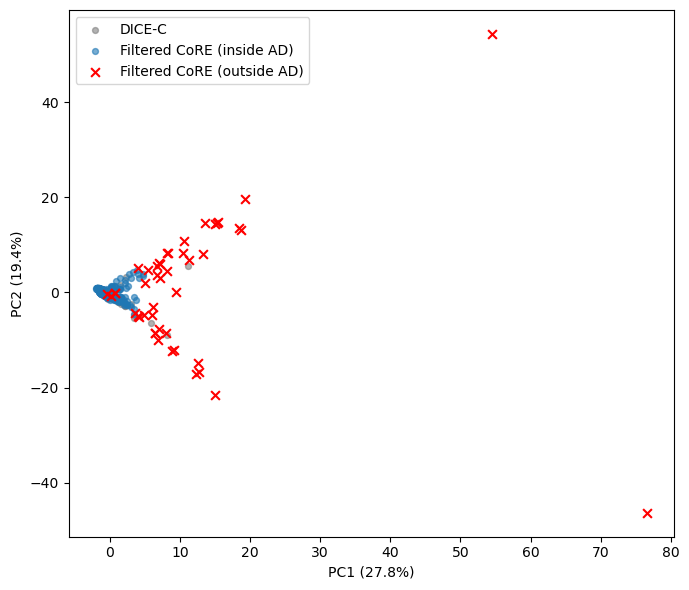

In [93]:
# PCA
pca = PCA(n_components=2, random_state=42)

X_all = np.vstack([X_dice_scaled, X_core_scaled])

scores = pca.fit_transform(X_all)

dice_scores = scores[:len(X_dice_scaled)]
core_scores = scores[len(X_dice_scaled):]

inside_scores = core_scores[inside_ad]
outside_scores = core_scores[~inside_ad]

plt.figure(figsize=(7,6))

plt.scatter(
    dice_scores[:,0],
    dice_scores[:,1],
    s=18,
    alpha=0.6,
    color="gray",
    label="DICE-C"
)

plt.scatter(
    inside_scores[:,0],
    inside_scores[:,1],
    s=18,
    alpha=0.6,
    color="tab:blue",
    label="Filtered CoRE (inside AD)"
)

plt.scatter(
    outside_scores[:,0],
    outside_scores[:,1],
    s=40,
    marker="x",
    linewidth=1.5,
    color="red",
    label="Filtered CoRE (outside AD)"
)

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")

plt.legend()
plt.tight_layout()
plt.show()

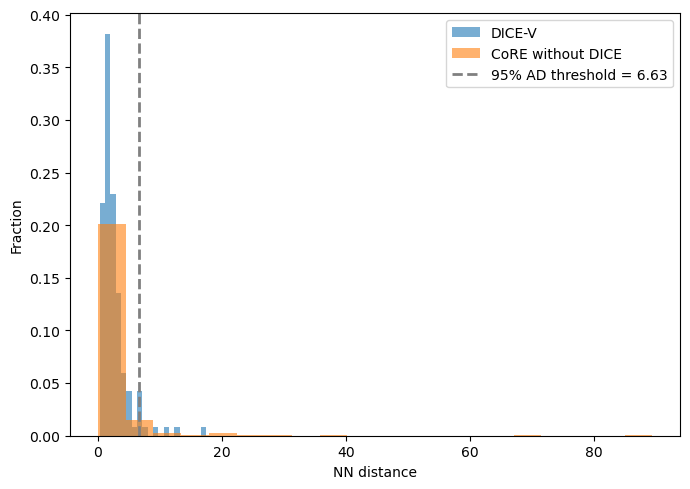

In [94]:
plt.figure(figsize=(7,5))

plt.hist(
    dice_internal_nn_distance,
    bins=20,
    alpha=0.6,
    density=True,
    label="DICE-V"
)

plt.hist(
    core_to_dice_distance,
    bins=20,
    alpha=0.6,
    density=True,
    label="CoRE without DICE"
)

plt.axvline(
    ad_threshold_95,
    color="grey",
    linestyle="--",
    linewidth=2,
    label=f"95% AD threshold = {ad_threshold_95:.2f}"
)

plt.xlabel("NN distance")
plt.ylabel("Fraction")

plt.legend()

plt.tight_layout()
plt.savefig("./AD_DICE.png")
plt.show()

In [95]:
ood_df = core_filtered_df.loc[~inside_ad].copy()

ood_df["nearest_training_distance"] = core_to_dice_distance[~inside_ad]

ood_df["nearest_training_cof"] = (
    dice_df.iloc[
        core_nearest_dice_index[~inside_ad]
    ]["cof_id"].values
)

ood_df = ood_df.sort_values(
    "nearest_training_distance",
    ascending=False
)

print(ood_df.shape)
ood_df[
    [
        "cof_id",
        "nearest_training_distance",
        "nearest_training_cof"
    ]
]
ood_df[
    [
        "cof_id",
        "nearest_training_distance",
        "nearest_training_cof"
    ]
].to_csv('./ood_cofs.csv', index = False)

(46, 35)


In [34]:
ood_df[
    [
        "cof_id",
        "nearest_training_distance",
        "nearest_training_cof"
    ]
]

,cof_id,nearest_training_distance,nearest_training_cof
628,69,89.448670,955
193,133,68.760033,68
645,712,36.424130,664
802,938,27.624953,664
280,264,22.480625,68
622,684,21.963649,955
514,548,19.703913,68
675,763,19.676290,183
310,311,19.298683,955
567,601,19.244357,68
